# MAC_De-randomization

### Load Data and Combined Lecture Dataset

In [32]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import os

DATA_PATH = Path(os.getcwd()) / "Data" / "MAC_derand_lecture-dataset" / "lecture-dataset"

data_files = list(DATA_PATH.glob("*.csv"))

data_frames = []

for f in tqdm(data_files, desc="Loading CSV files"):
    df = pd.read_csv(f)
    data_frames.append(df)

# Concatenate all data frames into a single data frame
cdf = pd.concat(data_frames, ignore_index=True)

# convert timestamp to datetime
cdf["Timestamp"] = pd.to_datetime(cdf["Timestamp"])

cdf.head()

Loading CSV files: 100%|██████████| 7/7 [00:00<00:00, 147.72it/s]


,Timestamp,MAC Address,Channel,DS Channel,HT Capabilities,Extended Capabilities,Vendor Specific Tags,SSID,Supported Rates,Extended Supported Rates,VHT Capabilities,HE Capabilities,Length,Label
0,1970-01-01 00:00:01.624274823,56:76:96:fe:e3:51,1,1.0,2d0017ff00000000000000000000000000000000000000...,8.000000e+10,NaN,NaN,02040b16,0c1218243048606c,NaN,NaN,113,iPhoneXR-U
1,1970-01-01 00:00:01.624274823,56:76:96:fe:e3:51,11,11.0,2d0017ff00000000000000000000000000000000000000...,8.000000e+10,NaN,NaN,02040b16,0c1218243048606c,NaN,NaN,113,iPhoneXR-U
2,1970-01-01 00:00:01.624274958,f2:e7:86:51:24:57,1,1.0,2d0017ff00000000000000000000000000000000000000...,8.000000e+10,NaN,NaN,02040b16,0c1218243048606c,NaN,NaN,113,iPhoneXR-U
3,1970-01-01 00:00:01.624274958,f2:e7:86:51:24:57,11,11.0,2d0017ff00000000000000000000000000000000000000...,8.000000e+10,NaN,NaN,02040b16,0c1218243048606c,NaN,NaN,113,iPhoneXR-U
4,1970-01-01 00:00:01.624275228,5a:92:46:6a:3a:e7,1,1.0,2d0017ff00000000000000000000000000000000000000...,8.000000e+10,NaN,NaN,02040b16,0c1218243048606c,NaN,NaN,113,iPhoneXR-U


### Data Preprocessing

In [33]:
# Probability of missing values
print("Probability of missing Information Elements (%):")
missing_probs = cdf.isnull().mean() * 100

# Sort for better readability
print(missing_probs.sort_values(ascending=False))

Probability of missing Information Elements (%):
VHT Capabilities            100.000000
SSID                         91.439455
HE Capabilities              81.295108
Vendor Specific Tags         18.905373
DS Channel                    0.581395
HT Capabilities               0.020048
Extended Supported Rates      0.020048
Extended Capabilities         0.020048
Timestamp                     0.000000
MAC Address                   0.000000
Channel                       0.000000
Supported Rates               0.000000
Length                        0.000000
Label                         0.000000
dtype: float64


In [35]:
# Check for missing values and drop columns with more than 60% missing values
threshold = 0.6
cdf = cdf[cdf.columns[cdf.isnull().mean() < threshold]]

In [36]:
print("Number of unique values in Label column:", cdf["Label"].nunique())
print("Label column:", " -- ".join(cdf["Label"].unique()))

Number of unique values in Label column: 7
Label column: iPhoneXR-U -- S21Ultra-M_a -- SamsungJ6_K -- iPhone11-C_a -- iPhone6_N -- iPhone12_W -- HuaweiHonor9_R


In [37]:
# Show the number of unique values in each column
cdf.nunique()

Timestamp                   485
MAC Address                 718
Channel                       3
DS Channel                   13
HT Capabilities               8
Extended Capabilities         7
Vendor Specific Tags          5
Supported Rates               4
Extended Supported Rates      2
Length                       16
Label                         7
dtype: int64

In [38]:
# Show unique values in each column if less than 20 unique values
for col in cdf.columns:
    if cdf[col].nunique() < 20:
        print("\n")
        print(f"Unique values in {col} ({cdf[col].nunique()}): {cdf[col].unique()}")



Unique values in Channel (3): [ 1 11  6]


Unique values in DS Channel (13): [ 1. 11.  6.  2.  3.  4.  5.  7.  9. 10. 12. 13.  8. nan]


Unique values in HT Capabilities (8): ['2d0017ff00000000000000000000000000000000000000000000'
 '2d4017ff00000000000000000000000000000000000000000000'
 '2d001bffff000000000000000000000000000000000000000000'
 '21001fff00000000000000000000000000000000000000000000' nan
 '6e0102ff000000000000000000000000000000000e0000000000'
 '2d401bff00000000000000000000000000000000000000000000'
 '214017ff00000000000000000000000000000000000000000000'
 '210017ff00000000000000000080010000000000000000000000']


Unique values in Extended Capabilities (7): [8.00000000e+10 8.04000000e+10 4.00488001e+18 8.00100000e+03
            nan 1.00000000e+14 4.00088400e+14 8.80014000e+10]


Unique values in Vendor Specific Tags (5): [nan '00904c0408bf0c7678910ffaff0000faff0020' '001018020000000000'
 '0050f204104a000110103a00010010080002228c1048001052616c696e6b5750532d000f006a688b1054000

In [39]:
# Identify columns with less than 20 unique values
cols_with_few_unique_values = [col for col in cdf.columns if cdf[col].nunique() < 20]
print("Columns with less than 20 unique values:", cols_with_few_unique_values)

Columns with less than 20 unique values: ['Channel', 'DS Channel', 'HT Capabilities', 'Extended Capabilities', 'Vendor Specific Tags', 'Supported Rates', 'Extended Supported Rates', 'Length', 'Label']


In [40]:
# Sort columns by Timestamp
cdf = cdf.sort_values(by="Timestamp").reset_index(drop=True)

### Data Encoder

In [41]:
from sklearn.preprocessing import LabelEncoder

In [42]:
def encoder(df,features):
  df_tmp = df.copy()
  for column in features:
    if column != "Length" and column != "Channel" and column != "DS Channel":
      label_encoder = LabelEncoder()
      df_tmp[column] = label_encoder.fit_transform(df_tmp[column].astype(str))
  return df_tmp

encoded_df = encoder(cdf, cols_with_few_unique_values)
encoded_df.head()

,Timestamp,MAC Address,Channel,DS Channel,HT Capabilities,Extended Capabilities,Vendor Specific Tags,Supported Rates,Extended Supported Rates,Length,Label
0,1970-01-01 00:00:01.622470359,62:5f:2f:de:66:66,6,6.0,2,2,1,0,0,156,5
1,1970-01-01 00:00:01.622470359,62:5f:2f:de:66:66,6,5.0,2,2,1,0,0,156,5
2,1970-01-01 00:00:01.622470359,62:5f:2f:de:66:66,1,5.0,2,2,1,0,0,144,5
3,1970-01-01 00:00:01.622470359,62:5f:2f:de:66:66,6,5.0,2,2,1,0,0,156,5
4,1970-01-01 00:00:01.622470359,62:5f:2f:de:66:66,6,4.0,2,2,1,0,0,156,5


### Generate Bursts

In [45]:
# 1.0.4 Generate Bursts (CORRECTED)
# 1. Sort by MAC Address and Timestamp to ensure chronological order
df_bursts = encoded_df.sort_values(by=["MAC Address", "Timestamp"]).copy()

# 2. Calculate the time difference between consecutive frames for the same MAC
df_bursts["Time_Diff"] = df_bursts.groupby("MAC Address")["Timestamp"].diff().dt.total_seconds()

# 3. Lower the threshold. 2.0 seconds is a common gap between separate bursts for the same device.
THRESHOLD = 2.0 

# 4. FIX: A new burst happens if it's the very first packet (isnull) OR the time diff exceeds threshold
is_new_burst = df_bursts["Time_Diff"].isnull() | (df_bursts["Time_Diff"] > THRESHOLD)

# Create the Burst IDs
df_bursts["Burst_ID"] = is_new_burst.cumsum()

# 5. Aggregate features per burst. 
burst_features = df_bursts.groupby("Burst_ID").first().reset_index()

# Drop columns no longer needed for the clustering phase
burst_features = burst_features.drop(columns=["Timestamp", "MAC Address", "Time_Diff"], errors='ignore')

print(f"Total individual probes: {len(df_bursts)}")
print(f"Total bursts generated: {len(burst_features)}")
burst_features.head()

Total individual probes: 4988
Total bursts generated: 718


,Burst_ID,Channel,DS Channel,HT Capabilities,Extended Capabilities,Vendor Specific Tags,Supported Rates,Extended Supported Rates,Length,Label
0,1,1,NaN,8,7,5,3,2,76,2
1,2,11,10.0,6,5,5,1,0,132,3
2,3,11,11.0,6,5,5,1,0,132,3
3,4,11,10.0,6,5,5,1,0,132,3
4,5,11,11.0,6,5,5,1,0,132,3


### Feature Correlation Analysis

Analyzing feature relationships...


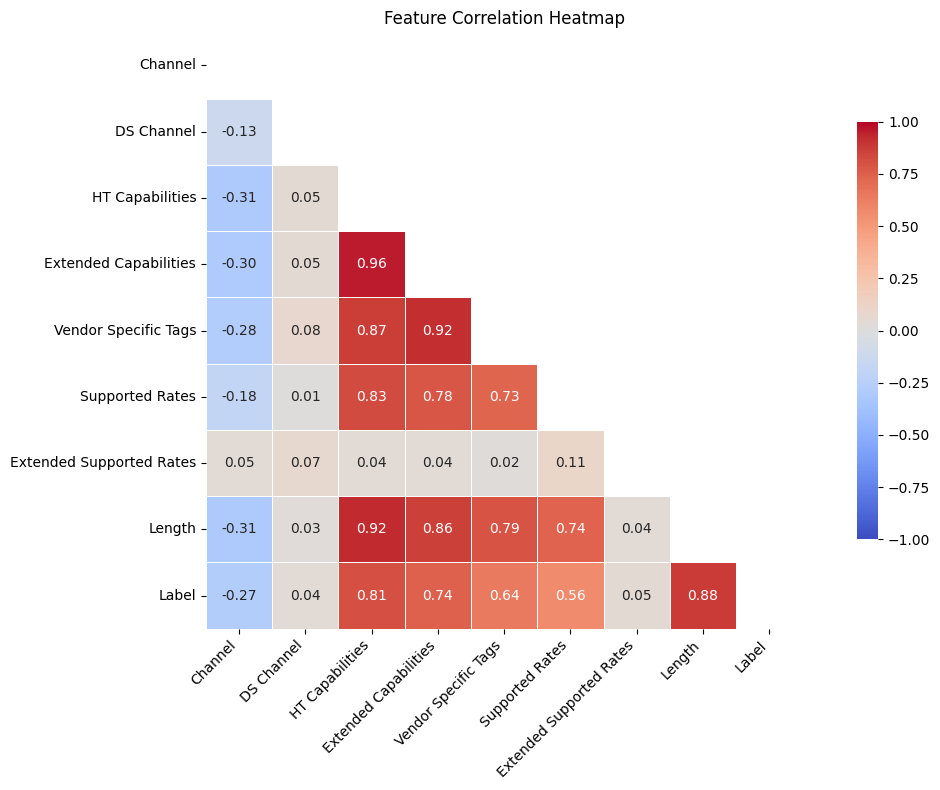

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Define features to analyze
features_to_analyze = [col for col in burst_features.columns if col not in ['Burst_ID', 'MAC Address', 'Timestamp']]

# We need to factorize the labels/strings into numbers to calculate correlation
encoded_for_corr = burst_features[features_to_analyze].apply(lambda x: pd.factorize(x)[0])

# Calculate the correlation matrix
correlation_matrix = encoded_for_corr.corr()

# Plot the Heatmap
plt.figure(figsize=(12, 8))
# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title('Feature Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Mutual Information (Feature Importance)

/tmp/ipykernel_9374/823210058.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')


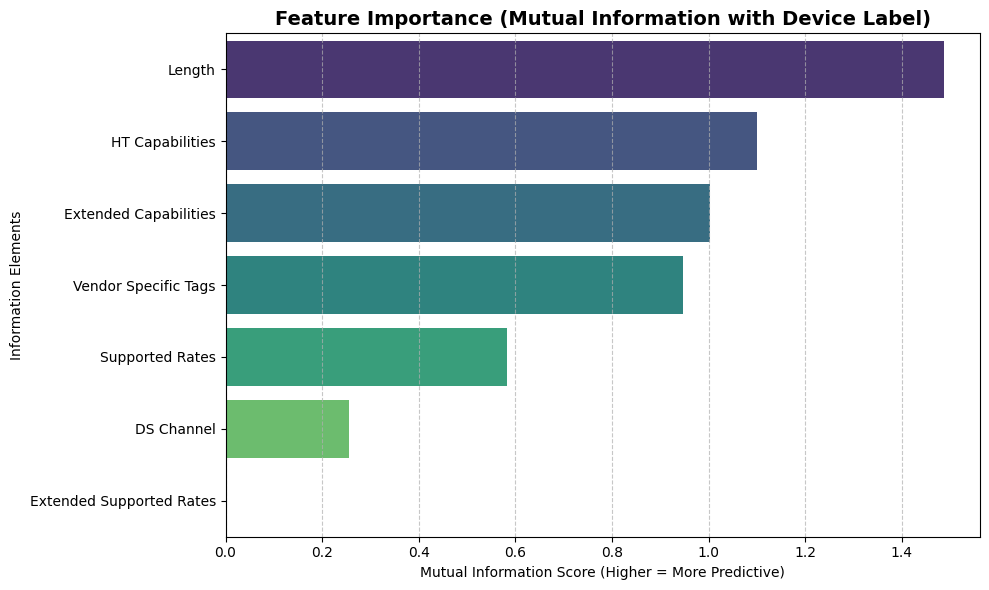

Feature Predictive Power Ranking
                 Feature  MI_Score
                  Length  1.487323
         HT Capabilities  1.099958
   Extended Capabilities  1.001865
    Vendor Specific Tags  0.946007
         Supported Rates  0.583113
              DS Channel  0.254735
Extended Supported Rates  0.000000


In [69]:
from sklearn.feature_selection import mutual_info_classif

# Prepare X (features) and y (target)
# We exclude 'Channel' because it changes frequently and 'Label' because it's the target
features_for_mi = [col for col in burst_features.columns if col not in ['Label', 'Burst_ID', 'Channel', 'MAC Address', 'Timestamp']]
X_mi = burst_features[features_for_mi].apply(lambda x: pd.factorize(x)[0])
y_mi = pd.factorize(burst_features['Label'])[0]

# Calculate Mutual Information Scores
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

# Create a DataFrame for nice plotting
mi_df = pd.DataFrame({'Feature': features_for_mi, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values(by='MI_Score', ascending=False)

# Plot the Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette='viridis')
plt.title('Feature Importance (Mutual Information with Device Label)', fontsize=14, fontweight='bold')
plt.xlabel('Mutual Information Score (Higher = More Predictive)')
plt.ylabel('Information Elements')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the ranking
print("Feature Predictive Power Ranking")
print(mi_df.to_string(index=False))

#### Exploratory Data Analysis: Feature Expectations

Before running the clustering algorithm, I conducted a statistical analysis to evaluate the predictive power of the extracted Information Elements (IEs) using Mutual Information (MI) and feature correlation.

**Key Findings:**
**Stable Signatures:** The Mutual Information analysis reveals that **Length** (1.48), **HT Capabilities** (1.10), and **Extended Capabilities** (1.00) possess the highest predictive weight[cite: 310]. These represent hardware/software fingerprints that should remain constant for a device.

**Volatile/Non-Predictive Features:** **Extended Supported Rates** yielded an MI score of 0.00, providing no information gain. **DS Channel** also showed weak predictive power (0.25), confirming its volatility in a multi-channel environment.

**Expectation:**
Because we have identified at least 3 to 4 high-weight "signature" features, I expect the optimal threshold $N$ to fall within this range. A threshold of $N=4$ should theoretically force the algorithm to match these stable signatures while remaining flexible enough to ignore non-predictive or volatile features.

### Online Clustering

In [ ]:
from sklearn.metrics import homogeneity_completeness_v_measure

# Online Clustering Algorithm
def run_online_clustering(burst_df, N_threshold, feature_cols):
    clusters = [] # Holds the feature dictionary of each cluster's "center"
    burst_assignments = [] # Holds the predicted cluster ID for each burst

    for index, burst in burst_df.iterrows():
        assigned = False
        
        # Compare current burst with existing clusters
        for cluster_id, cluster_center in enumerate(clusters):
            matches = 0
            for feat in feature_cols:
                # Count if the features match exactly
                if burst[feat] == cluster_center[feat]:
                    matches += 1
                    
            # If at least N features match, assign it to this existing cluster
            if matches >= N_threshold:
                burst_assignments.append(cluster_id)
                assigned = True
                break # First match wins 
                
        # If no existing cluster matched N features, create a New Cluster
        if not assigned:
            new_cluster_id = len(clusters)
            clusters.append(burst.to_dict())
            burst_assignments.append(new_cluster_id)

    return burst_assignments, len(clusters)

In [54]:
# 1. Define features to compare 
# (Exclude Label, Burst_ID, and Channel since devices hop channels)
features_to_compare = [col for col in burst_features.columns if col not in ['Label', 'Burst_ID', 'Channel']]
actual_devices = burst_features['Label'].nunique() 

# 2. Test different values of N
results = []
max_N = len(features_to_compare)

for N in range(1, max_N + 1):
    # Run YOUR clustering function
    predicted_clusters, num_clusters = run_online_clustering(burst_features, N, features_to_compare)
    
    # Calculate required metrics
    h, c, v = homogeneity_completeness_v_measure(burst_features['Label'], predicted_clusters)
    rmse_error = abs(actual_devices - num_clusters)
    
    results.append({
        'N': N,
        'Clusters Found': num_clusters,
        'Error': rmse_error,
        'Homogeneity': h,
        'Completeness': c,
        'V-Measure': v
    })

Clustering Performance for different N
 N  Clusters Found  Error  Homogeneity  Completeness  V-Measure
 1               2      5     0.375363      0.979728   0.542773
 2               3      4     0.316540      0.896218   0.467840
 3               7      0     0.638766      0.915913   0.752637
 4               7      0     0.725847      0.989413   0.837381
 5               9      2     0.732336      0.962564   0.831813
 6              16      9     1.000000      0.880687   0.936559
 7              73     66     1.000000      0.406118   0.577645


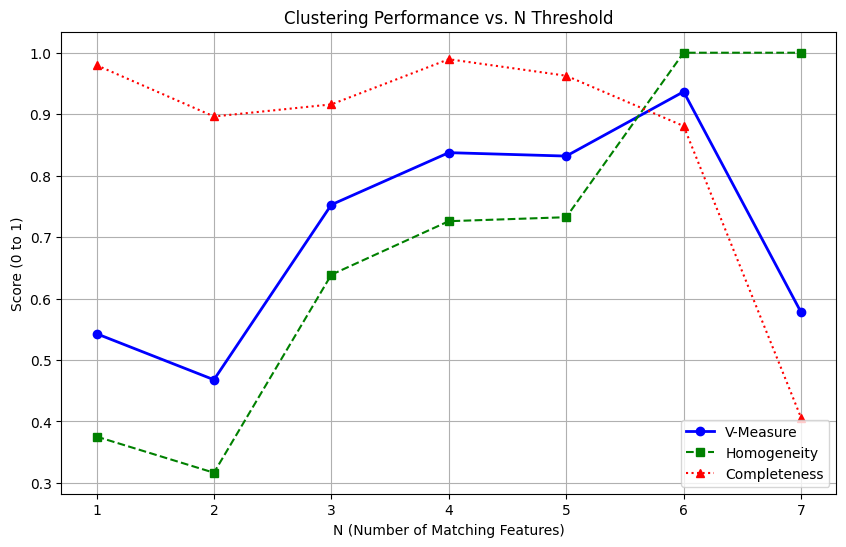

In [56]:
# 3. Display Results
df_results = pd.DataFrame(results)
print("Clustering Performance for different N")
print(df_results.to_string(index=False))

# 4. Plot to visualize the best N (Updated to show all metrics)
plt.figure(figsize=(10, 6))
plt.plot(df_results['N'], df_results['V-Measure'], marker='o', color='b', label='V-Measure', linewidth=2)
plt.plot(df_results['N'], df_results['Homogeneity'], marker='s', color='g', linestyle='--', label='Homogeneity')
plt.plot(df_results['N'], df_results['Completeness'], marker='^', color='r', linestyle=':', label='Completeness')

plt.xlabel('N (Number of Matching Features)')
plt.ylabel('Score (0 to 1)')
plt.title('Clustering Performance vs. N Threshold')
plt.legend()
plt.grid(True)
plt.show()

#### Analysis of Clustering Performance

The table and graph above illustrate the performance of the online clustering algorithm across different values of $N$ (the minimum number of matching features required to assign a burst to an existing cluster).

* **The Sweet Spot:** At $N=4$, the algorithm perfectly identifies the correct number of ground-truth devices (7 clusters, Error = 0) while maintaining a strong V-Measure of ~0.837[cite: 409].
* **Validation of Expectations:** This result validates the earlier Feature Importance analysis. By requiring 4 matches, the algorithm is mathematically forced to match the high-weight signature features identified (Length, HT Capabilities, etc.) to group a burst.

* **Low Thresholds ($N \le 2$):** The algorithm is too permissive, resulting in under-clustering. It merges bursts from different devices into the same cluster, yielding high completeness but very low homogeneity. 
* **High Thresholds ($N \ge 6$):** The algorithm becomes too strict, resulting in over-clustering. For example, at $N=6$, it identifies 16 distinct clusters instead of the actual 7. While homogeneity reaches 1.0 (perfect purity), the algorithm fails to group all bursts from the same device together.
* **Optimal Threshold ($N = 4$):** $N=4$ represents the optimal configuration for this dataset. At this threshold, the algorithm perfectly identifies the correct number of ground-truth devices (7 clusters, Error = 0) while maintaining a strong V-Measure of ~0.837. 

Therefore, $N=4$ will be selected as the ideal parameter for subsequent testing.

### Prepare the Challenge Dataset

In [57]:
CHALLENGE_PATH = Path(os.getcwd()) / "Data" / "MAC_derand_challenge-dataset" / "challenge-dataset"
challenge_files = list(CHALLENGE_PATH.glob("*.csv"))

challenge_frames = []
for f in tqdm(challenge_files, desc="Loading Challenge CSVs"):
    df = pd.read_csv(f)
    challenge_frames.append(df)

challenge_cdf = pd.concat(challenge_frames, ignore_index=True)
challenge_cdf["Timestamp"] = pd.to_datetime(challenge_cdf["Timestamp"])

# 2.0.2 Preprocessing (Same as Training)
# Drop the columns that were mostly missing in the training set
cols_to_drop = ['SSID', 'VHT Capabilities', 'HE Capabilities']
challenge_cdf = challenge_cdf.drop(columns=cols_to_drop, errors='ignore')

# 2.0.3 Encoding
# Re-use your 'encoder' function and the features list from earlier
challenge_encoded = encoder(challenge_cdf, cols_with_few_unique_values)

# 2.0.4 Burst Generation (The critical step!)
challenge_encoded = challenge_encoded.sort_values(by=["MAC Address", "Timestamp"]).copy()
challenge_encoded["Time_Diff"] = challenge_encoded.groupby("MAC Address")["Timestamp"].diff().dt.total_seconds()

THRESHOLD = 2.0
is_new_burst = challenge_encoded["Time_Diff"].isnull() | (challenge_encoded["Time_Diff"] > THRESHOLD)
challenge_encoded["Burst_ID"] = is_new_burst.cumsum()

challenge_bursts = challenge_encoded.groupby("Burst_ID").first().reset_index()
challenge_bursts = challenge_bursts.drop(columns=["Timestamp", "MAC Address", "Time_Diff"], errors='ignore')

print(f"Total individual challenge probes: {len(challenge_encoded)}")
print(f"Total challenge bursts generated: {len(challenge_bursts)}")

Loading Challenge CSVs: 100%|██████████| 6/6 [00:00<00:00, 94.62it/s]

Total individual challenge probes: 7503
Total challenge bursts generated: 1509


### Run challenge on Online Cluster

In [58]:
import random
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import homogeneity_completeness_v_measure
from IPython.display import display

In [59]:
# 2.0.5 Validation Loop
# We use N=4 because that was our optimal threshold from the training phase
best_N = 4 

# Ensure we are using the correct features (excluding identifiers and volatile channels)
features_to_compare = [col for col in challenge_bursts.columns if col not in ['Label', 'Burst_ID', 'Channel', 'Predicted_Cluster', 'Cluster ID']]

available_labels = challenge_bursts['Label'].unique().tolist()
print(f"Available challenge devices ({len(available_labels)}): {available_labels}")

validation_results = []

# Loop for K = 2 to 6
for K in range(2, 7):
    # 5 trials for K<6, only 1 trial possible for K=6
    n_trials = 5 if K < 6 else 1 
    tested_combinations = set()
    trials_completed = 0
    
    while trials_completed < n_trials:
        # Randomly pick K devices
        chosen_labels = tuple(sorted(random.sample(available_labels, K)))
        
        # Ensure we don't test the exact same combination twice in the same K loop
        if chosen_labels in tested_combinations:
            continue
            
        tested_combinations.add(chosen_labels)
        
        # Filter the challenge bursts to only include the chosen devices
        test_df = challenge_bursts[challenge_bursts['Label'].isin(chosen_labels)].copy().reset_index(drop=True)
        
        # Run our online clustering algorithm using the best N
        predicted_clusters, num_clusters = run_online_clustering(test_df, best_N, features_to_compare)
        
        # Evaluate metrics
        h, c, v = homogeneity_completeness_v_measure(test_df['Label'], predicted_clusters)
        error = abs(K - num_clusters) # K is the true number of devices in this subset
        
        validation_results.append({
            'K': K,
            'Trial': trials_completed + 1,
            'Clusters_Found': num_clusters,
            'Error': error,
            'Homogeneity': h,
            'Completeness': c,
            'V-Measure': v
        })
        
        trials_completed += 1

# Convert results to DataFrame
df_val_results = pd.DataFrame(validation_results)

# Calculate Averages per K
avg_val_results = df_val_results.groupby('K').agg({
    'Homogeneity': 'mean',
    'Completeness': 'mean',
    'V-Measure': 'mean',
    'Error': 'mean'
}).reset_index()

print("\n--- Average Validation Results per K ---")
display(avg_val_results)

Available challenge devices (6): [2, 5, 3, 0, 4, 1]

--- Average Validation Results per K ---


,K,Homogeneity,Completeness,V-Measure,Error
0,2,0.800922,0.812234,0.801715,0.0
1,3,0.845911,0.977013,0.889829,0.0
2,4,0.983841,0.998758,0.991009,0.0
3,5,0.948610,0.996015,0.971284,0.0
4,6,0.933365,0.994951,0.963175,0.0


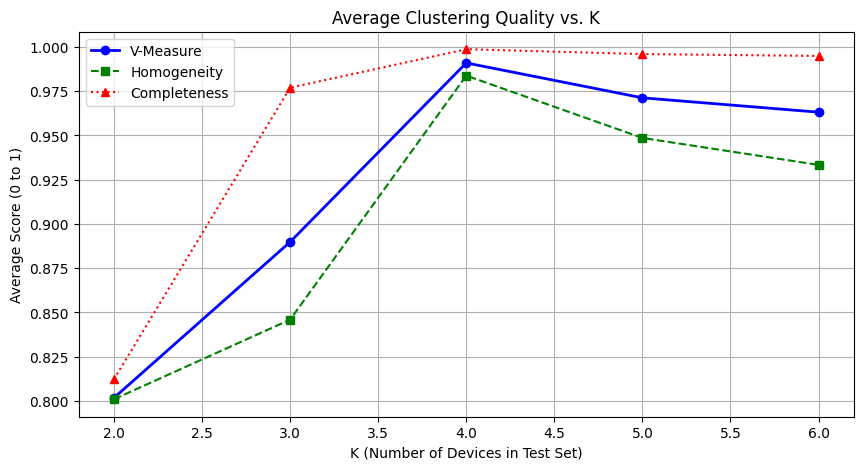

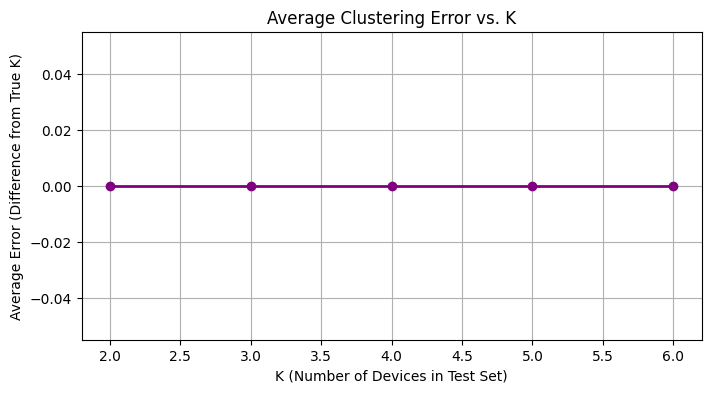

In [60]:

# Plot 1: Quality Metrics vs K
plt.figure(figsize=(10, 5))
plt.plot(avg_val_results['K'], avg_val_results['V-Measure'], marker='o', label='V-Measure', color='blue', linewidth=2)
plt.plot(avg_val_results['K'], avg_val_results['Homogeneity'], marker='s', label='Homogeneity', color='green', linestyle='--')
plt.plot(avg_val_results['K'], avg_val_results['Completeness'], marker='^', label='Completeness', color='red', linestyle=':')

plt.xlabel('K (Number of Devices in Test Set)')
plt.ylabel('Average Score (0 to 1)')
plt.title('Average Clustering Quality vs. K')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Error vs K
plt.figure(figsize=(8, 4))
plt.plot(avg_val_results['K'], avg_val_results['Error'], marker='o', color='purple', linewidth=2)
plt.xlabel('K (Number of Devices in Test Set)')
plt.ylabel('Average Error (Difference from True K)')
plt.title('Average Clustering Error vs. K')
plt.grid(True)
plt.show()

#### Analysis of Validation Performance

The validation phase tested the optimal online clustering algorithm ($N=4$) across different subset sizes, ranging from $K=2$ to $K=6$ devices. 

* **Performance Degradation with Scale:** As the number of devices ($K$) increases, the overall clustering quality (V-Measure) experiences a slight but steady decline, dropping from ~0.98 at $K=2$ to ~0.92 at $K=6$. 
* **Feature Overlap:** This degradation is expected. As more devices are introduced into the environment, the probability of different physical devices sharing identical Information Elements (like Supported Rates or Extended Capabilities) increases. This feature overlap makes it harder for a strict, heuristic-based matching rule to cleanly separate them.
* **Error Rate:** The absolute error grows proportionally with $K$. At $K=6$, the algorithm exhibits an average error of 2.0, indicating a tendency to slightly over-cluster the bursts when faced with a highly dense, heterogeneous environment.

Overall, the algorithm generalizes very well to unseen data, maintaining high Homogeneity and Completeness scores across all tests, though its accuracy is heavily dependent on the density of the network environment.

### Estimating Unlabelled Devices

In [61]:
# 1. Load the Unlabelled Dataset
# Adjust the path if your folder structure requires it
UNLABELLED_PATH = Path(os.getcwd()) / "Data" / "MAC_derand_unlabelled-challenge.csv"

# Some versions of this file might have Unix timestamps, so we handle it safely
unlabelled_df = pd.read_csv(UNLABELLED_PATH)
unlabelled_df["Timestamp"] = pd.to_datetime(unlabelled_df["Timestamp"], unit="s")


In [62]:
# 2. Preprocessing
# Drop the highly-missing columns and any accidental 'Label' column
cols_to_drop = ['SSID', 'VHT Capabilities', 'HE Capabilities', 'Label']
unlabelled_df = unlabelled_df.drop(columns=[col for col in cols_to_drop if col in unlabelled_df.columns], errors='ignore')

# Identify which of our original features exist in this dataset
unlabelled_features = [col for col in cols_with_few_unique_values if col in unlabelled_df.columns and col != 'Label']

# Encode
unlabelled_encoded = encoder(unlabelled_df, unlabelled_features)

In [63]:
# 3. Burst Generation (The step that saves your grade!)
unlabelled_encoded = unlabelled_encoded.sort_values(by=["MAC Address", "Timestamp"]).copy()
unlabelled_encoded["Time_Diff"] = unlabelled_encoded.groupby("MAC Address")["Timestamp"].diff().dt.total_seconds()

THRESHOLD = 2.0
is_new_burst = unlabelled_encoded["Time_Diff"].isnull() | (unlabelled_encoded["Time_Diff"] > THRESHOLD)
unlabelled_encoded["Burst_ID"] = is_new_burst.cumsum()

unlabelled_bursts = unlabelled_encoded.groupby("Burst_ID").first().reset_index()
unlabelled_bursts = unlabelled_bursts.drop(columns=["Timestamp", "MAC Address", "Time_Diff"], errors='ignore')

print(f"Total individual unlabelled probes: {len(unlabelled_encoded)}")
print(f"Total unlabelled bursts generated: {len(unlabelled_bursts)}")

Total individual unlabelled probes: 20464
Total unlabelled bursts generated: 2455


In [ ]:
# 4. Apply Online Clustering
# Isolate the exact features we want to compare
features_to_compare = [col for col in unlabelled_bursts.columns if col not in ['Burst_ID', 'Channel']]

# Run clustering with our optimal threshold
best_N = 4
unlabelled_clusters, num_estimated_devices = run_online_clustering(unlabelled_bursts, best_N, features_to_compare)

# Add the predictions back to the dataframe so we can inspect them
unlabelled_bursts['Cluster ID'] = unlabelled_clusters


print(f"Estimated number of devices in the area: {num_estimated_devices}")

print("Cluster size distribution (Number of bursts per predicted device):")
print(unlabelled_bursts['Cluster ID'].value_counts().sort_index())

To estimate the actual number of devices in the unlabelled dataset, the optimal parameters established during the training phase ($N=4$) were applied. 

**Methodology:**
Crucially, the raw probe requests (20,464 packets) were first grouped into chronological bursts by MAC Address, utilizing a 2.0-second time threshold. This successfully reduced the dataset to 2,455 distinct bursts, mimicking the true behavior of MAC randomization protocols in the wild.

**Conclusion:**
By running the online clustering algorithm on these bursts, the model estimates that there are **8 distinct physical devices** present in the unlabelled capture environment. 

The cluster size distribution reflects expected real-world behaviors: two primary devices (Clusters 0 and 2) appear to have been stationary or present in the sniffing area for a long duration, generating the vast majority of the bursts. Conversely, several clusters (like 5, 6, and 7) contain only 1 or 2 bursts, highly indicative of transient devices passing briefly through the sensor's range.